In [1]:
import requests
import pandas as pd
from pathlib import Path
import json

CLEANED_FILE = "/kaggle/input/datasets/ahsanrizvimeow/amazon-product-intelligence-cleaned/products_cleaned.json"

with open(CLEANED_FILE, encoding="utf-8") as f:
    products = json.load(f)
pdf = pd.DataFrame(products)
print(f"Loaded {len(pdf)} products")

IMAGE_DIR = Path("/kaggle/working/images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

failed = []
for i, row in pdf.iterrows():
    url = row["main_image_url"]
    asin = row["asin"]
    if not url:
        failed.append(asin)
        continue
    dest = IMAGE_DIR / f"{asin}.jpg"
    if dest.exists():
        continue
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        dest.write_bytes(resp.content)
    except Exception:
        failed.append(asin)
    if (i + 1) % 100 == 0:
        print(f"{i+1}/{len(pdf)}")

print(f"\nDownloaded: {len(list(IMAGE_DIR.glob('*.jpg')))}")
print(f"Failed: {len(failed)}")

Loaded 1005 products
100/1005
200/1005
300/1005
400/1005
500/1005
600/1005
700/1005
800/1005
900/1005
1000/1005

Downloaded: 1004
Failed: 1


In [2]:
import shutil
shutil.make_archive("/kaggle/working/product_images", "zip", "/kaggle/working/images")

import os
size_mb = os.path.getsize("/kaggle/working/product_images.zip") / (1024**2)
print(f"Created product_images.zip ({size_mb:.1f} MB)")

Created product_images.zip (31.2 MB)


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [4]:
%pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer
from PIL import Image
import numpy as np
from pathlib import Path

model = SentenceTransformer("clip-ViT-B-32")

image_paths = sorted(IMAGE_DIR.glob("*.jpg"))
asins = [p.stem for p in image_paths]

images = []
valid_asins = []
for p, a in zip(image_paths, asins):
    try:
        img = Image.open(p).convert("RGB")
        images.append(img)
        valid_asins.append(a)
    except Exception as e:
        print(f"Could not open {a}: {e}")

print(f"Loaded {len(images)} images")

embeddings = model.encode(images, batch_size=32, show_progress_bar=True,
                          convert_to_numpy=True)
print(f"Embedding shape: {embeddings.shape}")

np.save("/kaggle/working/image_embeddings.npy", embeddings)
with open("/kaggle/working/embedding_asins.json", "w") as f:
    json.dump(valid_asins, f)
print("Saved embeddings.")

Note: you may need to restart the kernel to use updated packages.


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loaded 1004 images


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (1004, 512)
Saved embeddings.


k= 5  inertia= 37743.4  silhouette=0.0773
k=10  inertia= 32282.8  silhouette=0.1198
k=15  inertia= 27982.5  silhouette=0.1580
k=20  inertia= 26094.4  silhouette=0.1700
k=25  inertia= 24549.2  silhouette=0.1739
k=30  inertia= 23754.2  silhouette=0.1647
k=35  inertia= 22587.6  silhouette=0.1558
k=40  inertia= 22196.0  silhouette=0.1430


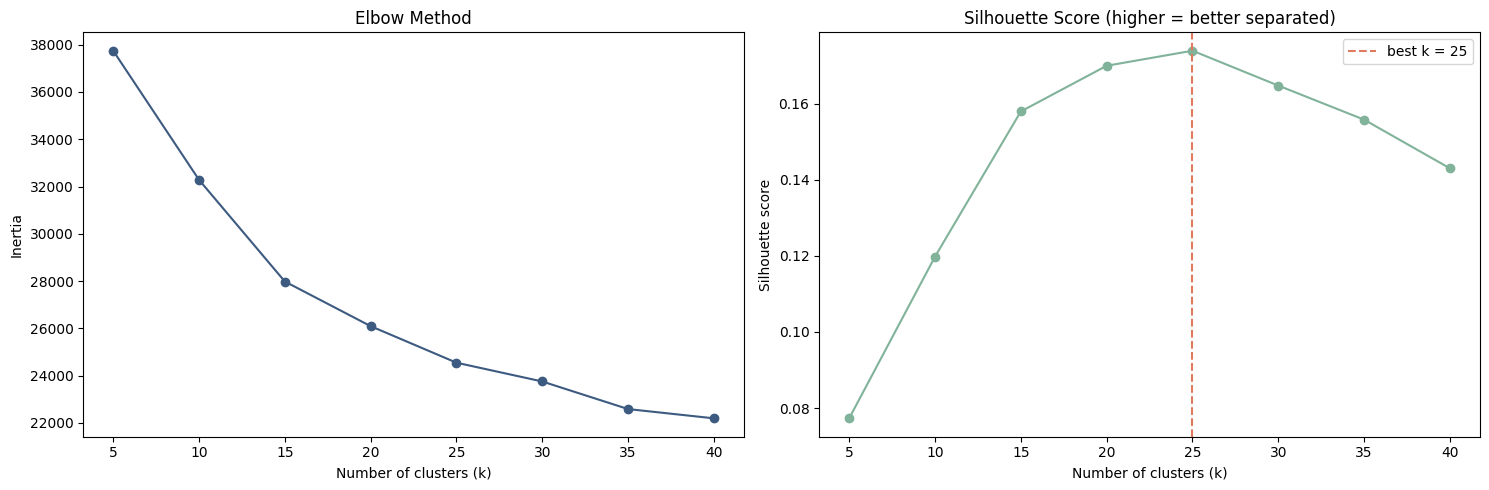


Best k by silhouette: 25
CLUSTERING ALGORITHM COMPARISON


,method,n_clusters,silhouette
0,KMeans (k=25),25,0.1739
1,Agglomerative (k=25),25,0.1643
2,DBSCAN,19,0.3731



DBSCAN noise points (unassigned): 853
KMeans           ARI=0.7896  NMI=0.8700
Agglomerative    ARI=0.7439  NMI=0.8547

(ARI/NMI near 1.0 = clusters closely match real categories,
 near 0 = no better than random grouping)

Cluster sizes:


cluster
0     45
1     21
2     39
3     34
4     58
5     48
6     48
7     55
8     50
9     63
10    58
11    22
12    57
13    59
14    61
15    17
16    47
17    35
18    21
19    16
20    19
21    26
22    53
23    32
24    20
Name: count, dtype: int64


Dominant category per cluster:


,size,dominant_category,purity_%
cluster,,,
0,45,yamaha acoustic guitar,97.8
1,21,instant pot,100.0
2,39,t-shirt,100.0
3,34,USB-C hub,64.7
4,58,sneakers,100.0
5,48,desk lamp LED,97.9
6,48,sunglasses,100.0
7,55,kitchen knife set,96.4
8,50,candle,94.0


In [5]:
# ============================================================
# CELL: Choose number of clusters
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(5, 41, 5)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings, labels))
    print(f"k={k:2d}  inertia={km.inertia_:8.1f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="#3d5a80")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#81b29a")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score (higher = better separated)")
best_k = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color="#e07a5f", linestyle="--", label=f"best k = {best_k}")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\nBest k by silhouette: {best_k}")


# ============================================================
# CELL: Compare clustering algorithms
# ============================================================
from sklearn.cluster import AgglomerativeClustering, DBSCAN

results = []

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km.fit_predict(embeddings)
results.append({"method": f"KMeans (k={best_k})",
                "n_clusters": best_k,
                "silhouette": silhouette_score(embeddings, km_labels)})

agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(embeddings)
results.append({"method": f"Agglomerative (k={best_k})",
                "n_clusters": best_k,
                "silhouette": silhouette_score(embeddings, agg_labels)})

db = DBSCAN(eps=4.0, min_samples=5)
db_labels = db.fit_predict(embeddings)
n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
if n_db > 1:
    mask = db_labels != -1
    db_sil = silhouette_score(embeddings[mask], db_labels[mask])
else:
    db_sil = float("nan")
results.append({"method": "DBSCAN",
                "n_clusters": n_db,
                "silhouette": db_sil})

results_df = pd.DataFrame(results).round(4)
print("=" * 60)
print("CLUSTERING ALGORITHM COMPARISON")
print("=" * 60)
display(results_df)
print(f"\nDBSCAN noise points (unassigned): {(db_labels == -1).sum()}")


# ============================================================
# CELL: Validate clusters against withheld category labels
# ============================================================
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

asin_to_cat = dict(zip(pdf["asin"], pdf["search_keyword"]))
true_cats = [asin_to_cat[a] for a in valid_asins]

for name, labels in [("KMeans", km_labels), ("Agglomerative", agg_labels)]:
    ari = adjusted_rand_score(true_cats, labels)
    nmi = normalized_mutual_info_score(true_cats, labels)
    print(f"{name:15s}  ARI={ari:.4f}  NMI={nmi:.4f}")

print("\n(ARI/NMI near 1.0 = clusters closely match real categories,")
print(" near 0 = no better than random grouping)")

cluster_df = pd.DataFrame({
    "asin": valid_asins,
    "category": true_cats,
    "cluster": km_labels,
})

print("\nCluster sizes:")
display(cluster_df["cluster"].value_counts().sort_index())

print("\nDominant category per cluster:")
purity = (cluster_df.groupby("cluster")["category"]
          .agg(lambda s: s.value_counts().index[0]))
purity_pct = (cluster_df.groupby("cluster")["category"]
              .agg(lambda s: s.value_counts().iloc[0] / len(s) * 100).round(1))
summary = pd.DataFrame({
    "size": cluster_df["cluster"].value_counts().sort_index(),
    "dominant_category": purity,
    "purity_%": purity_pct,
})
display(summary)

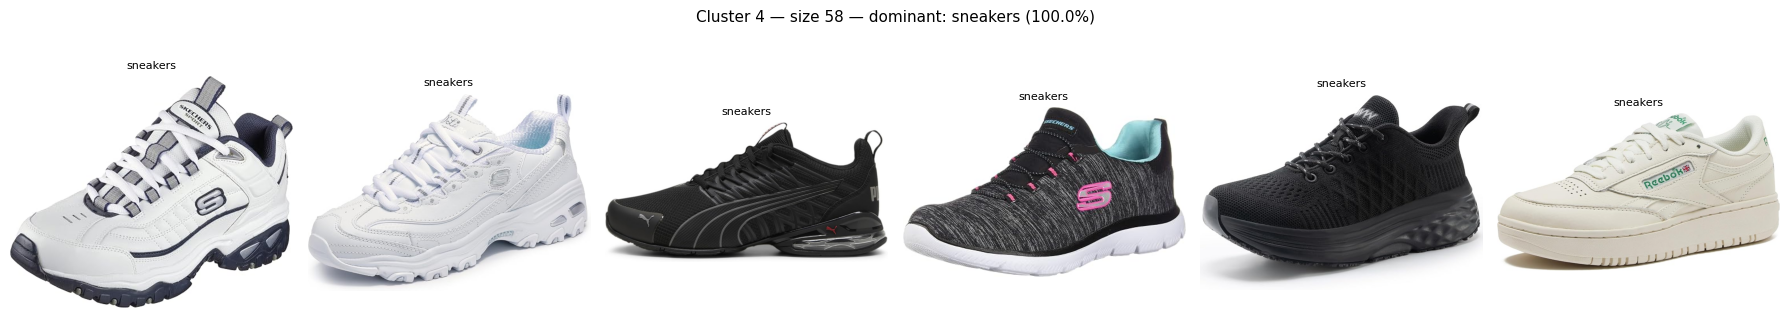

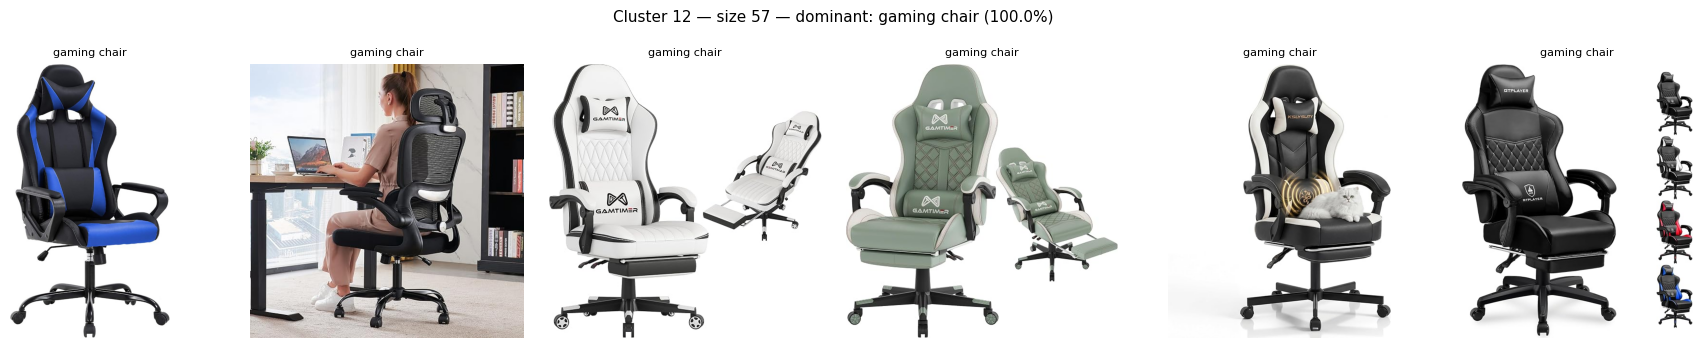

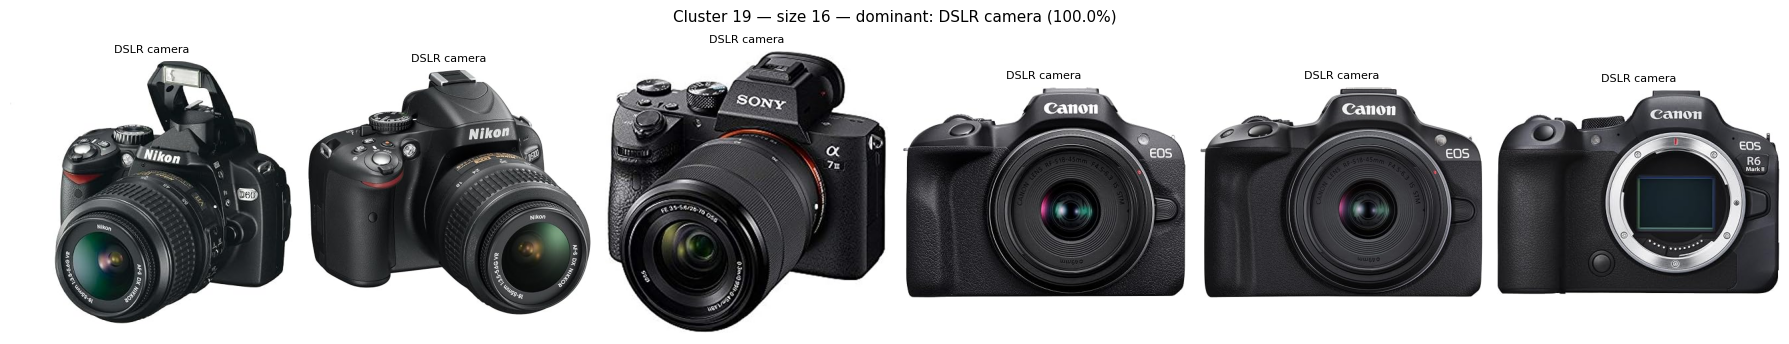


--- MIXED CLUSTERS (visually similar across categories) ---


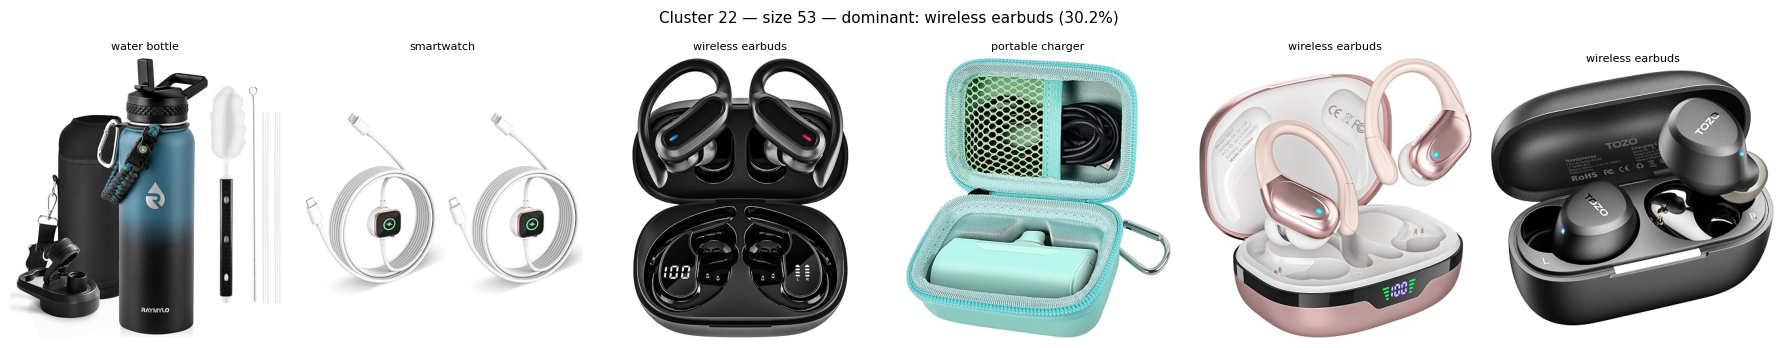

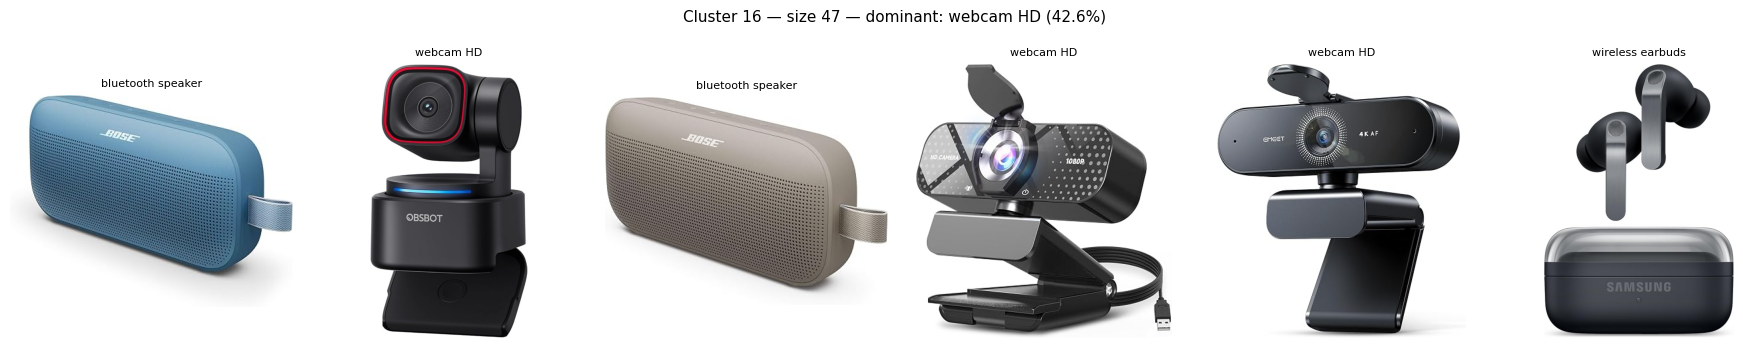

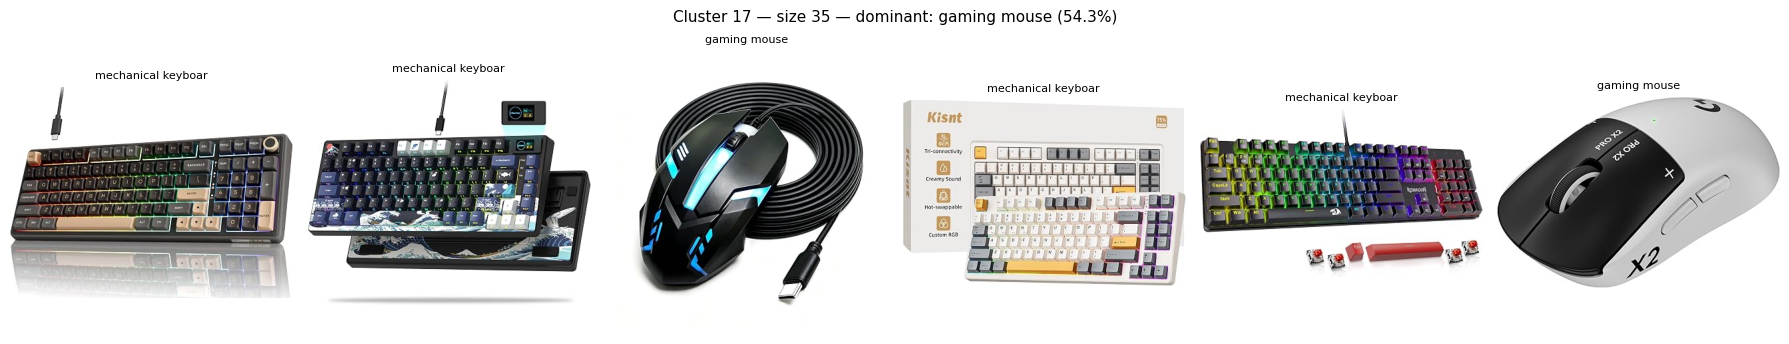

In [6]:
import matplotlib.image as mpimg

def show_cluster_samples(cluster_id, n=6):
    members = cluster_df[cluster_df["cluster"] == cluster_id]
    sample = members.sample(min(n, len(members)), random_state=42)
    dominant = summary.loc[cluster_id, "dominant_category"]
    purity = summary.loc[cluster_id, "purity_%"]

    fig, axes = plt.subplots(1, len(sample), figsize=(3*len(sample), 3.5))
    if len(sample) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, sample.iterrows()):
        img = mpimg.imread(IMAGE_DIR / f"{r['asin']}.jpg")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(r["category"][:18], fontsize=8)
    fig.suptitle(f"Cluster {cluster_id} — size {len(members)} — "
                 f"dominant: {dominant} ({purity}%)", fontsize=11)
    plt.tight_layout()
    plt.show()

for cid in [4, 12, 19]:
    show_cluster_samples(cid)

print("\n--- MIXED CLUSTERS (visually similar across categories) ---")
for cid in [22, 16, 17]:
    show_cluster_samples(cid)

In [8]:
import os
os.makedirs("/kaggle/working/models", exist_ok=True)

cluster_df.to_csv("/kaggle/working/models/feature_c_clusters.csv", index=False)
summary.to_csv("/kaggle/working/models/feature_c_cluster_summary.csv")
results_df.to_csv("/kaggle/working/models/feature_c_algorithm_comparison.csv", index=False)
np.save("/kaggle/working/models/feature_c_kmeans_centers.npy", km.cluster_centers_)
np.save("/kaggle/working/models/feature_c_image_embeddings.npy", embeddings)

with open("/kaggle/working/models/feature_c_embedding_asins.json", "w") as f:
    json.dump(valid_asins, f)

print("Saved:")
for f in sorted(os.listdir("/kaggle/working/models")):
    size_kb = os.path.getsize(f"/kaggle/working/models/{f}") / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

Saved:
  feature_c_algorithm_comparison.csv  (0.1 KB)
  feature_c_cluster_summary.csv  (0.6 KB)
  feature_c_clusters.csv  (26.8 KB)
  feature_c_embedding_asins.json  (13.7 KB)
  feature_c_image_embeddings.npy  (2008.1 KB)
  feature_c_kmeans_centers.npy  (50.1 KB)


In [10]:
import shutil

shutil.make_archive("/kaggle/working/feature_c_artifacts", "zip", "/kaggle/working/models")
shutil.make_archive("/kaggle/working/product_images", "zip", "/kaggle/working/images")

for name in ["feature_c_artifacts.zip", "product_images.zip"]:
    size_mb = os.path.getsize(f"/kaggle/working/{name}") / (1024**2)
    print(f"{name}: {size_mb:.1f} MB")

feature_c_artifacts.zip: 1.9 MB
product_images.zip: 31.2 MB
